In [ ]:
from iqm.qiskit_iqm import IQMProvider
import numpy as np
import pickle
from qiskit import QuantumCircuit
from qiskit.circuit.library import RGate, CZGate
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration, CompressiveGST
import os
os.environ[
    "IQM_TOKEN"
] = "UWcEU3ZP7mxzs7XBs4Lit7sht39u9wmoX/cQ6p3HsiMBmb9y++B244T70dk7QacX"

iqm_server_url = "https://cocos.resonance.meetiqm.com/garnet"
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/iqm/iqm_client/iqm_client.py:135: UserWarning: Could not verify IQM Client compatibility with the server. You might encounter issues. 2 validation errors for ClientLibrary
name
  Field required [type=missing, input_value={'min': '34.0.3', 'package_name': 'iqm-client'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.9/v/missing
max
  Field required [type=missing, input_value={'min': '34.0.3', 'package_name': 'iqm-client'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.9/v/missing
  warnings.warn(version_incompatibility_msg)


# Benchmark: Negative Rx and Ry

In [ ]:
gate_qubits = [[0], [1], [0], [1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]
num_qubits = 2
num_gates = 9
gates = [QuantumCircuit(num_qubits, 0) for _ in range(num_gates)]
# Rx(-pi/2) on qubit 0
gates[0].append(RGate(-0.5 * np.pi, 0), [0])
# Rx(-pi/2) on qubit 1
gates[1].append(RGate(-0.5 * np.pi, 0), [1])
# Ry(-pi/2) on qubit 0
gates[2].append(RGate(-0.5 * np.pi, 0.5 * np.pi), [0])
# Ry(-pi/2) on qubit 1
gates[3].append(RGate(-0.5 * np.pi, 0.5 * np.pi), [1])
# Rx(-pi/2) x Rx(-pi/2) on qubits 0 and 1
gates[4].append(RGate(-0.5 * np.pi, 0), [0])
gates[4].append(RGate(-0.5 * np.pi, 0), [1])
# Rx(-pi/2) x Ry(-pi/2) on qubits 0 and 1
gates[5].append(RGate(-0.5 * np.pi, 0), [0])
gates[5].append(RGate(-0.5 * np.pi, 0.5 * np.pi), [1])
# Ry(-pi/2) x Rx(-pi/2) on qubits 0 and 1
gates[6].append(RGate(-0.5 * np.pi, 0.5 * np.pi), [0])
gates[6].append(RGate(-0.5 * np.pi, 0), [1])
# Ry(-pi/2) x Ry(-pi/2) on qubits 0 and 1
gates[7].append(RGate(-0.5 * np.pi, 0.5 * np.pi), [0])
gates[7].append(RGate(-0.5 * np.pi, 0.5 * np.pi), [1])
gates[8].append(CZGate(), [[0], [1]])
gate_labels = [
    "Rx_pi_2_neg:0",
    "Rx_pi_2_neg:1",
    "Ry_pi_2_neg:0",
    "Ry_pi_2_neg:1",
    "Rx_pi_2_neg-Rx_pi_2_neg:0-1",
    "Rx_pi_2_neg-Ry_pi_2_neg:0-1",
    "Ry_pi_2_neg-Rx_pi_2_neg:0-1",
    "Ry_pi_2_neg-Ry_pi_2_neg:0-1",
    "CZ",
]
shots = 2**10
kraus_rank = 16
num_sequences = 2000 # as recommended by the GSTConfiguration
# max_gates_per_batch = 20000
max_circuits_per_batch = 100
seq_len_list = [1, 7, 14]
# qubits = [[0, 1]]# [7], [8], [9], [10], [11], [12], [13], [14], [15]]
GST_CONFIG = GSTConfiguration(
    qubit_layouts = [[0, 1]],
    gate_set=gates,
    gate_labels = gate_labels,
    num_circuits=num_sequences,
    shots=shots,
    rank=kraus_rank,
    seq_len_list = seq_len_list,
    max_circuits_per_batch = max_circuits_per_batch
)

benchmark = CompressiveGST(backend, GST_CONFIG)

In [42]:
# save GST configuration for later use
with open("gst_config_negative.pkl", "wb") as f:
    pickle.dump(GST_CONFIG, f)

In [4]:
benchmark.gate_labels

{'[0, 1]': {0: 'Rx_pi_2_neg:0',
  1: 'Rx_pi_2_neg:1',
  2: 'Ry_pi_2_neg:0',
  3: 'Ry_pi_2_neg:1',
  4: 'Rx_pi_2_neg-Rx_pi_2_neg:0-1',
  5: 'Rx_pi_2_neg-Ry_pi_2_neg:0-1',
  6: 'Ry_pi_2_neg-Rx_pi_2_neg:0-1',
  7: 'Ry_pi_2_neg-Ry_pi_2_neg:0-1',
  8: 'CZ'}}

In [ ]:
result = benchmark.run()
# 10 minutes 34.7s

2026-05-29 00:08:33,475 - iqm.benchmarks.logging_config - INFO - Generating 2000 random GST circuits
2026-05-29 00:08:34,270 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2026-05-29 00:08:34,820 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQM Backend with optimization level 0, sabre routing method all circuits
2026-05-29 00:08:39,072 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1]
2026-05-29 00:08:39,073 - iqm.benchmarks.logging_config - INFO - max_circuits_per_batch restriction: submitting subbatch #1 with 100 circuits corresponding to qubits [0, 1]
/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/iqm/qiskit_iqm/iqm_provider.py:170: UserWarning: Unknown backend option(s): {'calibration_set_id'}
  warnings.warn(f'Unknown backend option(s): {unknown_options}')
2026-05-29 00:08:39,731 - iqm.benchmarks.logging_config -

# Save benchmark result

In [6]:
with open("run_result_neg.pkl", "wb") as f:
    pickle.dump(result, f)

# Reconstruction

In [22]:
import jax.numpy as jnp
from mGST.utility_functions_comparisons import get_compressed_perturbed_rep_from_mgst, kraus_tensor_to_mgst, target_kraus_tensor_from_configuration, get_full_mgst_parameters_from_result_and_configuration
from mGST.low_level_jit import cost_function_jax_mps
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.visualization import plot_cost_function

In [8]:
kraus_tensor_perturbed, kraus_superop_perturbed, povm_vect, state_vect, prob_matrix, indices_list = get_full_mgst_parameters_from_result_and_configuration(result=result, configuration=GST_CONFIG, only_jax_variables=True, seed=42
)

INFO:2026-05-29 00:20:46,745:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-05-29 00:20:46,745 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-05-29 00:20:46,750:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

In [9]:
kraus_tensor_perturbed.shape, povm_vect.shape, state_vect.shape, prob_matrix.shape, len(indices_list), kraus_superop_perturbed.shape

((9, 16, 4, 4), (4, 16), (16,), (4, 2000), 2000, (9, 16, 16))

In [15]:
dim = 2**2
num_povm = dim
rank_povm = dim
rank_state = dim

In [11]:
kraus_tensor_target = target_kraus_tensor_from_configuration(configuration=GST_CONFIG)
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_target)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/utility_functions_comparisons.py:184: UserWarning: No backend specified. Using 'iqmfakeapollo' as default backend.
  warnings.warn("No backend specified. Using 'iqmfakeapollo' as default backend.")


In [45]:
# Save
jnp.savez(
    "gst_args_and_targets_negative.npz",
    kraus_superop_target=kraus_superop_target,
    povm_vect=povm_vect,
    state_vect=state_vect,
    prob_matrix=prob_matrix,
    indices_list=np.array(indices_list, dtype=object),  # for list of arrays
    gate_labels=np.array(gate_labels),
)

In [16]:
kraus_tensor_init_jax = jnp.array(kraus_tensor_perturbed)
povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_mgst=povm_vect, state_mgst=state_vect, rank_povm=rank_povm, rank_state=rank_state)
print(povm_psd_init_jax.shape, state_psd_init_jax.shape)
print(jnp.count_nonzero(povm_vect), jnp.count_nonzero(state_vect))
print(jnp.count_nonzero(povm_psd_init_jax), jnp.count_nonzero(state_psd_init_jax))

(4, 4, 4) (4, 4)
4 1
16 4


In [17]:
jnp.savez("init_operators_perturbed_negative.npz",
          povm_psd_init_jax=povm_psd_init_jax,
          state_psd_init_jax=state_psd_init_jax,
          kraus_tensor_init_jax=kraus_tensor_init_jax,
          )

In [18]:
init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

initial_cost_value = cost_function_jax_mps(*init_operators_jax.values(), **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 272 the new count changed to: 5
at iteration 454 the new count changed to: 6
at iteration 636 the new count changed to: 7
at iteration 818 the new count changed to: 8
at iteration 1000 the new count changed to: 9
at iteration 1142 the new count changed to: 10
at iteration 1285 the new count changed to: 11
at iteration 1428 the new count changed to: 12
at iteration 1571 the new count changed to: 13
at iteration 1714 the new count changed to: 14
at iteration 1857 the new count changed to: 15
Initial cost value: 0.00046407130125697735


## Optimization

In [19]:
num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1 # before by mistake we set it to 0.5 (WRONG)

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

relative_precision = 1e-5

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

In [ ]:
optimized_operators, cost_fn_history = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None,
    relative_precision=relative_precision,
    verbose=True,
)
# 16m 42.4s

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 4.640713e-04. |r∇f(x)|: 1.735206e-03. Radius: 1.00e-01
TCG finished after: 3/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 2.58e-06
---------------------------------------
TR Iteration: 1. f(x): 4.292029e-04. |r∇f(x)|: 6.257146e-06. Radius: 1.00e-01
TCG finished after: 6/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 1.794911e-06
Optimization finished ✅. 
 Iters: 2. f(x): 4.292024e-04. |r∇f(x)|: 3.114541e-09. Radius: 2.00e-01. Rejections: 0

 🎯 [Povm] Relative change in cost function value: 3.49e-05. Target: 1.00e-05.
🚀 TR started for operat

In [24]:
noise_floor = estimate_noise_floor_threshold(prob_matrix, shots, multiplier=1.0)
noise_floor

Array(0.00014475, dtype=float64)

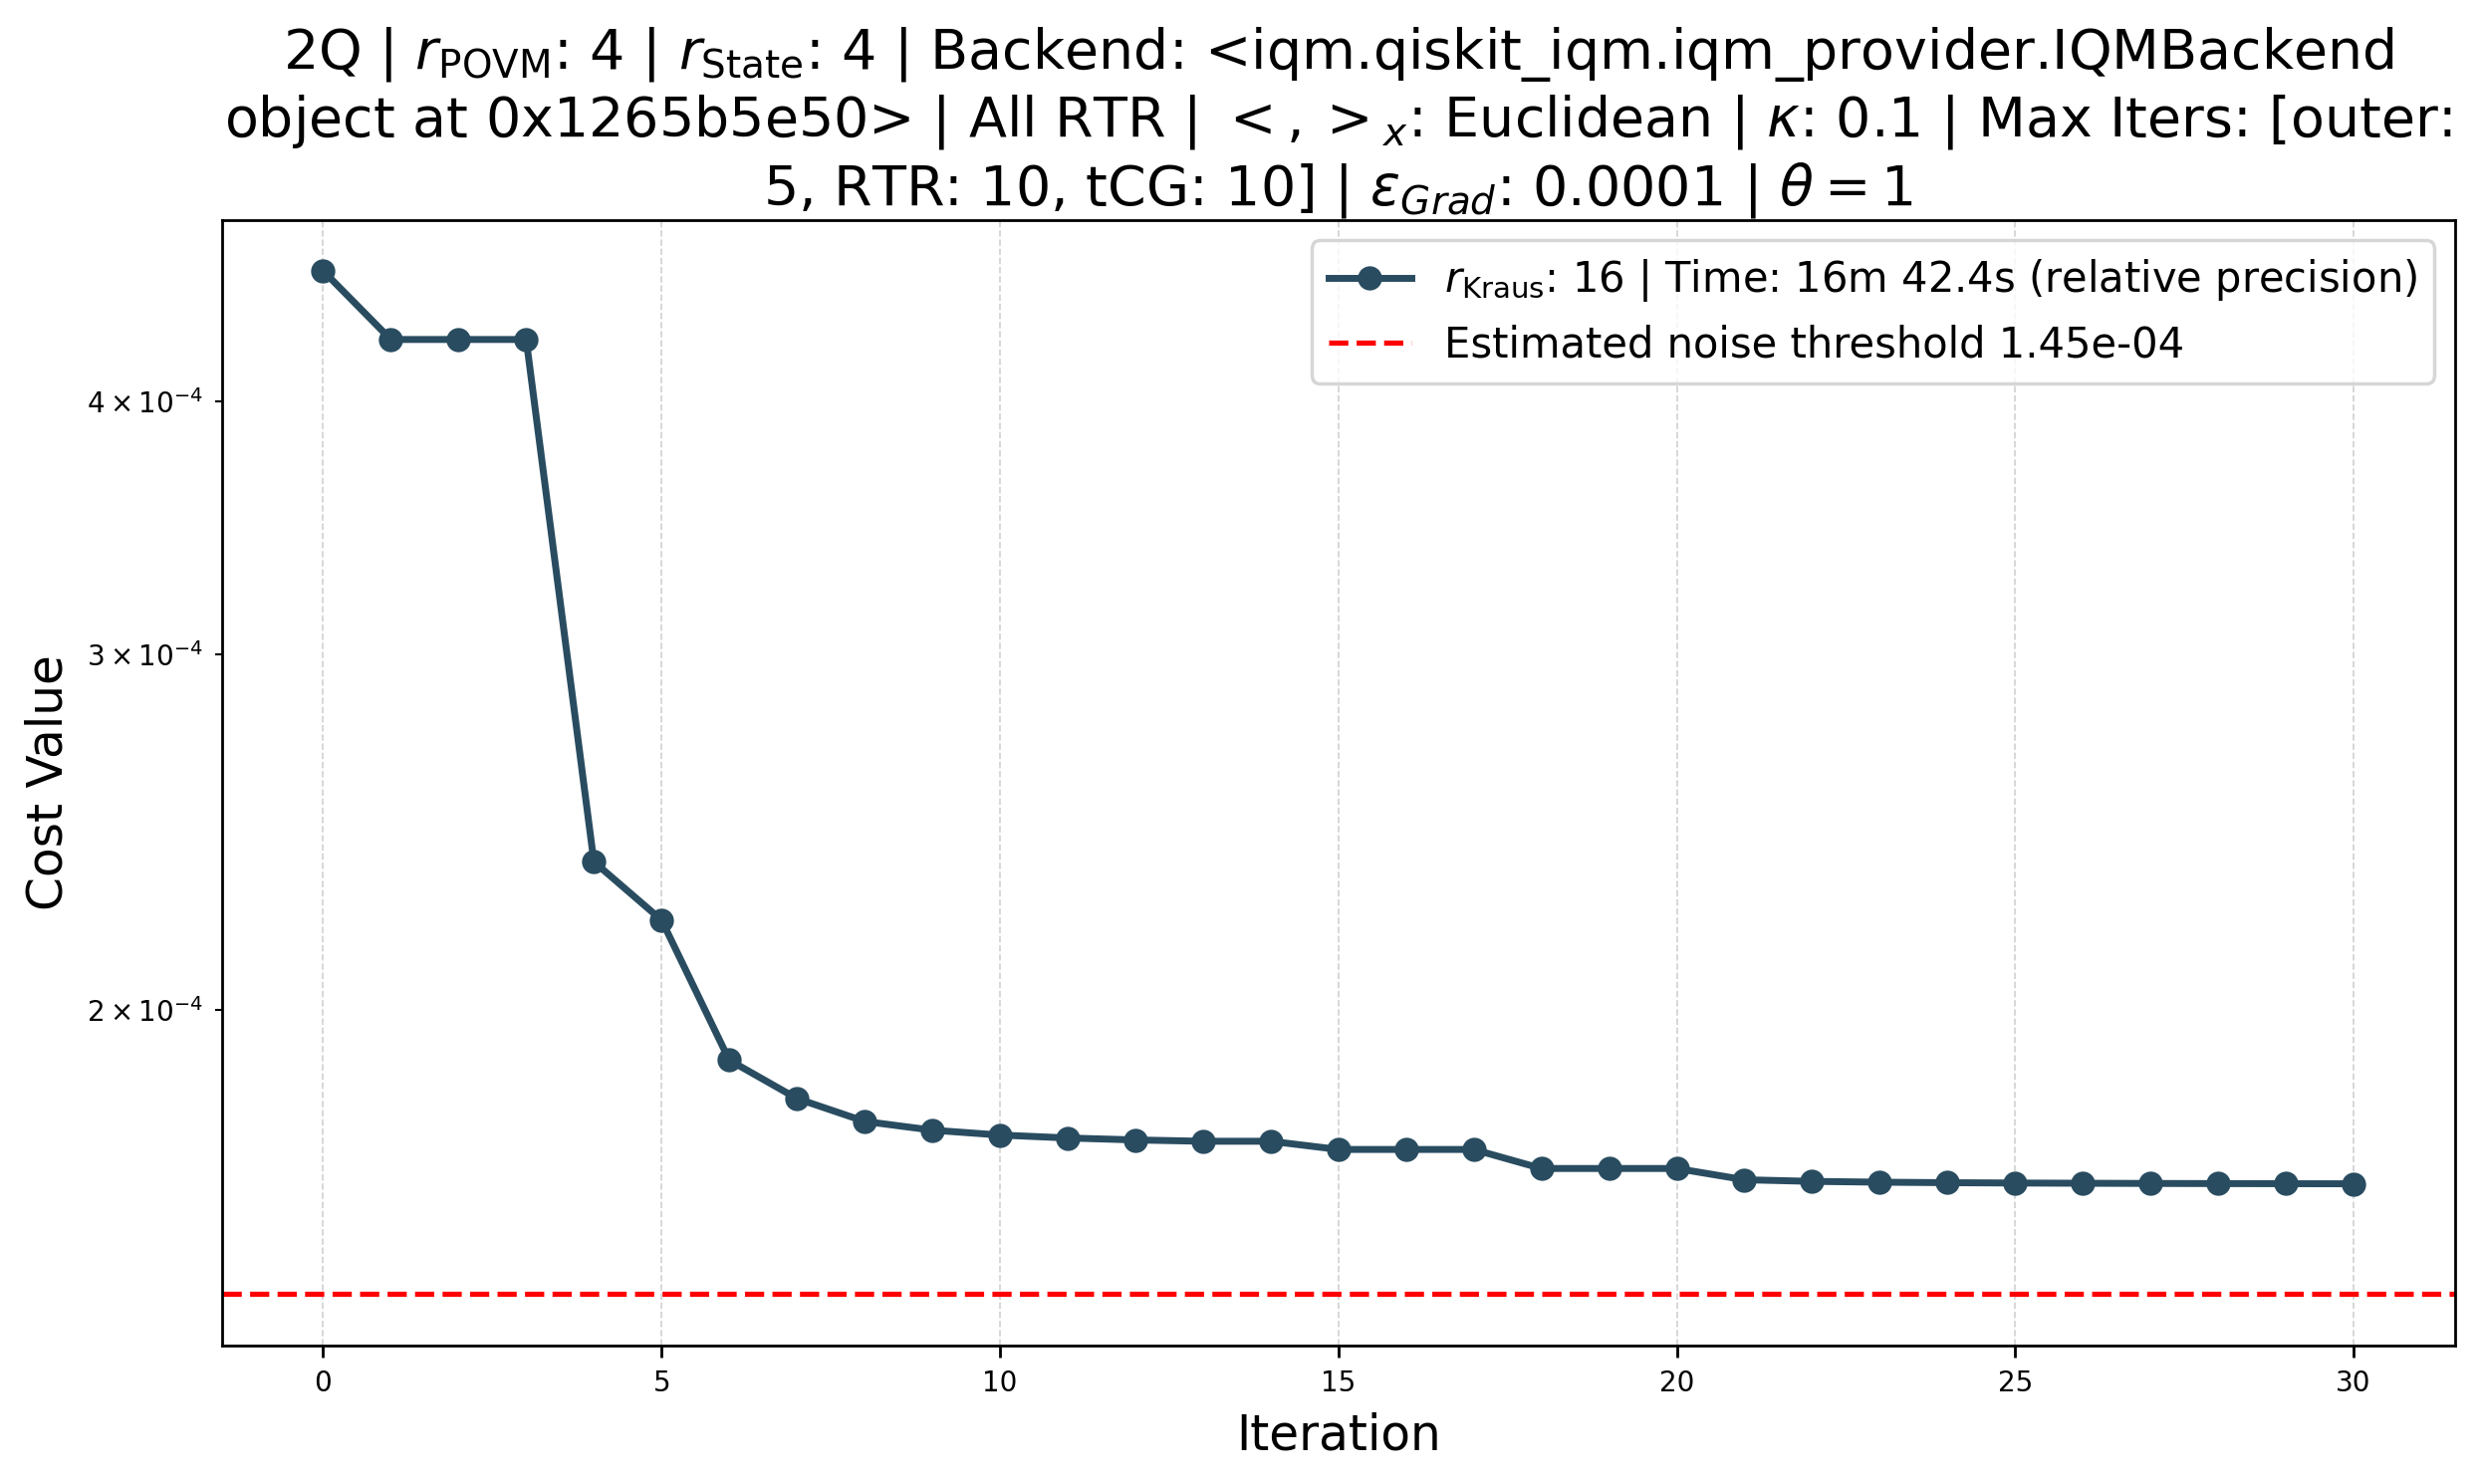

In [59]:
cost_fn_lists_ranks = [
    cost_fn_history,
]

labels_ranks = [
    rf"$r_\mathrm{{Kraus}}$: {kraus_rank} | Time: 16m 42.4s (relative precision)",
]

title_ranks = rf"2Q | $r_\mathrm{{POVM}}$: {rank_povm} | $r_\mathrm{{State}}$: {rank_state} | Backend: {backend} | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad} | $\theta=${theta}"

plot_cost_function(cost_fn_lists_ranks, title=title_ranks, labels=labels_ranks, comparison_yline=noise_floor, comparison_label=f"Estimated noise threshold {noise_floor:.2e}")

In [23]:
jnp.savez("optimized_negative.npz",
          kraus=optimized_operators["kraus"],
          povm=optimized_operators["povm"],
          state=optimized_operators["state"],
          )

# Gauge optimization

In [36]:
from mGST.compatibility import arrays_to_pygsti_model
from mGST.utility_functions_comparisons import get_mgst_tensors_from_psd_representation
from mGST.reporting.reporting import gauge_opt

In [35]:
gauge_weights = {'G0': 1,
 'G1': 1,
 'G2': 1,
 'G3': 1,
 'G4': 1,
 'G5': 1,
 'G6': 1,
 'G7': 1,
 'G8': 1,
 'spam': 0.1}

kraus_tensor_opt = optimized_operators["kraus"]
povm_psd_opt = optimized_operators["povm"]
state_psd_opt = optimized_operators["state"]

target_ops = {
    "X": kraus_superop_target,
    "E": povm_vect,
    "rho": state_vect,
}

target_model_pygsti = arrays_to_pygsti_model(**target_ops, basis="std")

print([op.shape for op in target_ops.values()])

optimized_ops_mgst = get_mgst_tensors_from_psd_representation(kraus_tensor_opt, povm_psd_opt, state_psd_opt)
[(key, op.shape) for key, op in optimized_ops_mgst.items()]

[(9, 16, 16), (4, 16), (16,)]


[('kraus', (9, 16, 16)), ('povm', (4, 16)), ('state', (16,))]

In [37]:
kraus_mgst_gauge_opt, povm_mgst_gauge_opt, state_mgst_gauge_opt = gauge_opt(
    X=optimized_ops_mgst["kraus"],
    E=optimized_ops_mgst["povm"],
    rho=optimized_ops_mgst["state"],
    target_mdl=target_model_pygsti,
    weights=gauge_weights)

In [38]:
# what are their shapes?
kraus_mgst_gauge_opt.shape, povm_mgst_gauge_opt.shape, state_mgst_gauge_opt.shape

((9, 16, 16), (4, 16), (16,))

In [39]:
jnp.savez(
    "optimized_gauge_negative.npz",
    kraus=kraus_mgst_gauge_opt,
    povm=povm_mgst_gauge_opt,
    state=state_mgst_gauge_opt,
)

# Check the Average gate fidelity is not outrageous

In [54]:
from mGST.low_level_jit import average_process_fidelity
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output

In [ ]:
kraus_tensor_est, *_ = get_compressed_rep_from_mgst_output(
    kraus_mgst=kraus_mgst_gauge_opt,
    povm_mgst=povm_mgst_gauge_opt,
    state_mgst=state_mgst_gauge_opt,
    kraus_rank=kraus_rank,
    povm_rank=rank_povm,
    state_rank=rank_state,
)

(9, 16, 4, 4)

In [58]:
gate_fidelities = {}
for gate_idx, gate_label in enumerate(gate_labels):
    avg_gate_fidelity = average_process_fidelity(
        kraus_tensor_est=kraus_tensor_est[gate_idx],
        kraus_tensor_target=kraus_tensor_target[gate_idx],
    )
    gate_fidelities[gate_label] = avg_gate_fidelity

gate_fidelities

{'Rx_pi_2_neg:0': Array(0.99423319, dtype=float64),
 'Rx_pi_2_neg:1': Array(0.99451426, dtype=float64),
 'Ry_pi_2_neg:0': Array(0.99490848, dtype=float64),
 'Ry_pi_2_neg:1': Array(0.99606089, dtype=float64),
 'Rx_pi_2_neg-Rx_pi_2_neg:0-1': Array(0.99571299, dtype=float64),
 'Rx_pi_2_neg-Ry_pi_2_neg:0-1': Array(0.9941416, dtype=float64),
 'Ry_pi_2_neg-Rx_pi_2_neg:0-1': Array(0.99373941, dtype=float64),
 'Ry_pi_2_neg-Ry_pi_2_neg:0-1': Array(0.99421757, dtype=float64),
 'CZ': Array(0.99023642, dtype=float64)}

# Creating a map between Gauge optimized operators/Target and their gate labels

In [46]:
gate_labels

['Rx_pi_2_neg:0',
 'Rx_pi_2_neg:1',
 'Ry_pi_2_neg:0',
 'Ry_pi_2_neg:1',
 'Rx_pi_2_neg-Rx_pi_2_neg:0-1',
 'Rx_pi_2_neg-Ry_pi_2_neg:0-1',
 'Ry_pi_2_neg-Rx_pi_2_neg:0-1',
 'Ry_pi_2_neg-Ry_pi_2_neg:0-1',
 'CZ']

In [49]:
gauged_superop_map = {
    label: superop for label, superop in zip(gate_labels, kraus_mgst_gauge_opt)
}

target_superop_map = {
    label: superop for label, superop in zip(gate_labels, kraus_superop_target)
}

In [52]:
jnp.savez(
    "gauged_superops_negative.npz",
    **gauged_superop_map,
)

jnp.savez(
    "target_superops_negative.npz",
    **target_superop_map,
)